# Multimodal Logistic Regression Classifier

**Thesis:** Predicting Agentic Pull Request Rejection: An Empirical Comparison
of NLP Approaches

**Author**: Victoria Angela Vizmonte

This notebook is the full end-to-end pipeline for the Multimodal Logistic
Regression Classifier, combining frozen CodeBERT diff embeddings, sBERT text
embeddings, and structured metadata features into a single logistic regression
classifier. Inference and embedding extraction cells are cache-guarded and will
load existing outputs without rerunning the model. The evaluation section
reproduces the full chart sequence and saves all outputs to
`results/final/multimodal_lr/`.

| Item | Description |
|---|---|
| Model | Logistic Regression (L-BFGS solver, balanced class weights) |
| Diff encoder | CodeBERT (`microsoft/codebert-base`), frozen, 768-dim |
| Text encoder | sBERT (`all-MiniLM-L6-v2`), frozen, 384-dim |
| Metadata encoder | Structured features, 69-dim |
| Total feature vector | 1,221-dim (768 + 384 + 69) |
| Diff chunking | Top-K=5 chunks, 512-token truncation, mean-pooled |
| Regularization | Tuned on validation set (C selected via PR-AUC) |
| Evaluation output | `results/final/multimodal_lr/` |

In [1]:
# ---------------------------------------------------------------
# CONFIGURE THIS PATH before running any other cell.
# Set DRIVE_BASE to the folder on your Google Drive that contains
# data/, src/, results/, and requirements.txt for this project.
# Example: if you placed the shared folder at the root of your
# Drive, set this to '/content/drive/MyDrive/AgenticPRRejection'
# ---------------------------------------------------------------
DRIVE_BASE = '/content/drive/MyDrive/Thesis/AgenticPRRejection'

from google.colab import drive
import subprocess, sys
from pathlib import Path

# Mount Google Drive
drive.mount('/content/drive')
print('Drive mounted')

# Point directly to src/ on Drive — no git clone needed
REPO_SRC = f'{DRIVE_BASE}/src'
sys.path.insert(0, REPO_SRC)
print(f'src/ added to path: {REPO_SRC}')

# Install dependencies once per session
subprocess.run(
    ['pip', 'install', '-q', '-r',
     f'{DRIVE_BASE}/requirements.txt'],
    check=True
)
print('Dependencies installed')

Mounted at /content/drive
Drive mounted
src/ added to path: /content/drive/MyDrive/Thesis/AgenticPRRejection/src
Dependencies installed


In [2]:
# Force reload evaluator to pick up any edits made on Drive
import importlib
if 'evaluator' in sys.modules:
    importlib.reload(sys.modules['evaluator'])
    import importlib as _il; _il.invalidate_caches()

# Imports
import logging
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

from data_loader import load_raw_tables
from model1_embedder import extract_and_save_embeddings, load_embeddings
from features.diff_features import build_diff_chunks
from preprocessing import load_processed_data
from preprocessing import ensure_fresh_processed_data
from splits import temporal_split
from model1_trainer import save_model, train_logistic_regression
from config import RANDOM_SEED
from config import PROCESSED_DATA_FILE

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s  %(levelname)-8s  %(name)s — %(message)s',
    datefmt='%H:%M:%S',
)
from features.text_features import PRTextEncoder
from features.metadata_features import PRMetadataEncoder
from features.feature_pipeline import FeaturePipeline
import joblib
from IPython.display import display as ipy_display
print('Imports OK')
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import average_precision_score
from sklearn.metrics import f1_score, precision_score, recall_score
from evaluator import (
    compute_metrics, save_metrics,
    display_metric_table_val, display_metric_table_test,
    plot_curves_summary, plot_diagnostics_summary,
    plot_metric_bars, run_group_ablation, run_subgroup_report,
    plot_subgroup_pr_auc, compute_subgroup_metrics, save_subgroup_metrics,
)


Imports OK


In [3]:
# Output paths (Colab / Drive)
DRIVE_BASE = Path(DRIVE_BASE)
print(f'DRIVE_BASE set to: {DRIVE_BASE}')
print(f'Exists on Drive:   {DRIVE_BASE.exists()}')
RESULTS_BASE   = DRIVE_BASE / 'results' / 'final' / 'multimodal_lr'
EMBEDDINGS_DIR = RESULTS_BASE / 'embeddings'
MODELS_DIR     = RESULTS_BASE
EVAL_DIR       = RESULTS_BASE
PIPELINE_PATH  = MODELS_DIR / 'feature_pipeline.joblib'

for d in [EMBEDDINGS_DIR, RESULTS_BASE]:
    d.mkdir(parents=True, exist_ok=True)

print('Output directories created:')
for d in [EMBEDDINGS_DIR, RESULTS_BASE]:
    print(' ', d)
print('Pipeline checkpoint path:', PIPELINE_PATH)

DRIVE_BASE set to: /content/drive/MyDrive/Thesis/AgenticPRRejection
Exists on Drive:   True
Output directories created:
  /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/embeddings
  /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr
Pipeline checkpoint path: /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/feature_pipeline.joblib


### Preprocess Data

In [4]:
# Load preprocessed data from Drive (runs preprocessing once if not cached)
# Staleness checks (missing columns, related_issue_count all-zero, empty filenames/file_changes)
# are handled inside ensure_fresh_processed_data() in src/preprocessing.py.

ensure_fresh_processed_data()
df = load_processed_data()
print(f'Total closed PRs : {len(df)}')
print(f'Merged   (label=0): {(df["label"] == 0).sum()}')
print(f'Rejected (label=1): {(df["label"] == 1).sum()}')

Total closed PRs : 10648
Merged   (label=0): 6700
Rejected (label=1): 3948


In [5]:
# Temporal split (70 / 15 / 15)
train_df, val_df, test_df = temporal_split(df)

for name, split in [('train', train_df), ('val', val_df), ('test', test_df)]:
    n = len(split)
    n_rej = (split['label'] == 1).sum()
    print(f'{name:5s}: {n:5d} PRs  |  rejected={n_rej} ({100*n_rej/n:.1f}%)')

train:  7453 PRs  |  rejected=2858 (38.3%)
val  :  1598 PRs  |  rejected=528 (33.0%)
test :  1597 PRs  |  rejected=562 (35.2%)


In [6]:
# Load pr_commit_details filtered to our PRs
all_pr_ids = set(df['id'].tolist())
tables = load_raw_tables(['pr_commit_details'])
commit_details = tables['pr_commit_details']
commit_details = commit_details[commit_details['pr_id'].isin(all_pr_ids)].copy()
print(f'pr_commit_details filtered to {len(commit_details):,} rows')

pr_commit_details filtered to 283,468 rows


In [7]:
# Build diff chunks for each split
train_chunks = build_diff_chunks(train_df, commit_details)
val_chunks   = build_diff_chunks(val_df,   commit_details)
test_chunks  = build_diff_chunks(test_df,  commit_details)

for name, chunks in [('train', train_chunks), ('val', val_chunks), ('test', test_chunks)]:
    n_empty = (~chunks['has_diff']).sum()
    print(f'{name:5s}: {len(chunks):5d} PRs  |  median_chunks={chunks["n_chunks"].median():.1f}  |  no_diff={n_empty}')

train:  7453 PRs  |  median_chunks=5.0  |  no_diff=0
val  :  1598 PRs  |  median_chunks=5.0  |  no_diff=0
test :  1597 PRs  |  median_chunks=5.0  |  no_diff=0


In [8]:
# Drop PRs with no extractable diff chunks
# Removes PRs whose patch text exists but yields no hunk content after
# parsing (would silently produce zero vectors during mean pooling).
from features.diff_features import drop_empty_chunks, assert_no_empty_chunks

filtered = {}
for split_name, chunks_df in [
    ('train', train_chunks),
    ('val',   val_chunks),
    ('test',  test_chunks),
]:
    before = len(chunks_df)
    chunks_df = drop_empty_chunks(chunks_df)
    dropped = before - len(chunks_df)
    print(f'Dropped (no extractable chunks): {dropped} [{split_name}]')
    assert_no_empty_chunks(chunks_df)
    filtered[split_name] = chunks_df

train_chunks = filtered['train']
val_chunks   = filtered['val']
test_chunks  = filtered['test']

# Realign the original split DataFrames to the retained PR IDs.
# split_df uses column 'id'; chunks DataFrames use column 'pr_id'.
train_df = train_df[train_df['id'].isin(train_chunks['pr_id'])].copy()
val_df   = val_df[val_df['id'].isin(val_chunks['pr_id'])].copy()
test_df  = test_df[test_df['id'].isin(test_chunks['pr_id'])].copy()

print(f'Retained: train={len(train_df)}, val={len(val_df)}, test={len(test_df)}')


Dropped (no extractable chunks): 0 [train]
Dropped (no extractable chunks): 0 [val]
Dropped (no extractable chunks): 0 [test]
Retained: train=7453, val=1598, test=1597


In [9]:
# Sample validation (50 PRs): verify pipeline shapes before full run
import torch
from model1_embedder import load_codebert, embed_chunks

VALIDATION_N = 50
sample = train_chunks.head(VALIDATION_N).reset_index(drop=True)

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# Find first PR with at least one valid chunk for shape checks (a), (b), (c)
valid_rows = sample[sample['has_diff']]
if valid_rows.empty:
    raise RuntimeError(f'None of the first {VALIDATION_N} PRs have extractable chunks.')

first_chunks = valid_rows.iloc[0]['diff_chunks']

# Load CodeBERT for validation; freed at the end of this cell
tokenizer_val, model_val = load_codebert(device=device)

# (a) Token tensor shape for one PR: should be (K, 512) where K = number of chunks (<= 5)
K = len(first_chunks)
encoded = tokenizer_val(
    first_chunks,
    max_length=512,
    truncation=True,
    padding=True,
    return_tensors='pt',
)
token_shape = tuple(encoded['input_ids'].shape)
print(f'(a) Token tensor shape for one PR : {token_shape}  (expected ({K}, 512))')
assert token_shape == (K, 512), f'Token tensor shape mismatch: {token_shape}'

# (b) CLS embedding from one chunk: should be (768,)
with torch.no_grad():
    single = tokenizer_val(
        [first_chunks[0]],
        max_length=512,
        truncation=True,
        padding=True,
        return_tensors='pt',
    )
    single = {k: v.to(device) for k, v in single.items()}
    out = model_val(**single)
    cls_vec = out.last_hidden_state[0, 0, :].cpu().numpy()
chunk_embed_shape = cls_vec.shape
print(f'(b) Single chunk CLS embedding    : {chunk_embed_shape}  (expected (768,))')
assert chunk_embed_shape == (768,), f'Chunk embedding shape mismatch: {chunk_embed_shape}'

# (c) Aggregated PR-level embedding after mean pooling across chunks: should be (768,)
pr_embed = embed_chunks(first_chunks, tokenizer_val, model_val, device=device)
pr_embed_shape = pr_embed.shape
print(f'(c) Aggregated PR-level embedding : {pr_embed_shape}  (expected (768,))')
assert pr_embed_shape == (768,), f'PR embedding shape mismatch: {pr_embed_shape}'

# (d) Count of PRs with fewer than 5 valid chunks (short diffs)
short_diff_count = (sample['n_chunks'] < 5).sum()
print(f'(d) PRs with <5 chunks (short diffs): {short_diff_count} / {VALIDATION_N}')

# (e) Label distribution in the 50-PR sample
n_accepted = (sample['label'] == 0).sum()
n_rejected = (sample['label'] == 1).sum()
print(
    f'(e) Label distribution: '
    f'accepted={n_accepted} ({100 * n_accepted / VALIDATION_N:.1f}%)  '
    f'rejected={n_rejected} ({100 * n_rejected / VALIDATION_N:.1f}%)'
)

# Free GPU memory before full extraction
del model_val, tokenizer_val
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print('\nAll validation checks passed. Safe to proceed to full embedding extraction.')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/498 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/150 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/499M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

(a) Token tensor shape for one PR : (5, 512)  (expected (5, 512))
(b) Single chunk CLS embedding    : (768,)  (expected (768,))
(c) Aggregated PR-level embedding : (768,)  (expected (768,))
(d) PRs with <5 chunks (short diffs): 12 / 50
(e) Label distribution: accepted=23 (46.0%)  rejected=27 (54.0%)

All validation checks passed. Safe to proceed to full embedding extraction.


In [10]:
# Extract CodeBERT embeddings (or load from cache)
# Cache guard: if embeddings and labels .npy files for all splits already exist
# in EMBEDDINGS_DIR, extraction is skipped entirely.
# Delete files from EMBEDDINGS_DIR to force re-extraction.
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

_SPLITS = [
    ("train", train_chunks),
    ("val",   val_chunks),
    ("test",  test_chunks),
]

for split_name, chunks_df in _SPLITS:
    emb_path = EMBEDDINGS_DIR / f"{split_name}_embeddings.npy"
    lbl_path = EMBEDDINGS_DIR / f"{split_name}_labels.npy"
    if emb_path.exists() and lbl_path.exists():
        print(f"[{split_name}] Cache found — skipping extraction.")
    else:
        print(f"[{split_name}] No cache — extracting embeddings...")
        extract_and_save_embeddings(chunks_df, split_name, EMBEDDINGS_DIR, device=device)

X_train, y_train = load_embeddings("train", EMBEDDINGS_DIR)
X_val,   y_val   = load_embeddings("val",   EMBEDDINGS_DIR)
X_test,  y_test  = load_embeddings("test",  EMBEDDINGS_DIR)

print(f"X_train: {X_train.shape}  y_train: {y_train.shape}")
print(f"X_val  : {X_val.shape}  y_val  : {y_val.shape}")
print(f"X_test : {X_test.shape}  y_test : {y_test.shape}")


Using device: cuda
[train] Cache found — skipping extraction.
[val] Cache found — skipping extraction.
[test] Cache found — skipping extraction.
X_train: (7453, 768)  y_train: (7453,)
X_val  : (1598, 768)  y_val  : (1598,)
X_test : (1597, 768)  y_test : (1597,)


In [11]:
# Load FeaturePipeline from cache, or fit from scratch if absent.
# To force re-fit (e.g. after changing ACTIVE_FEATURES or encoder config),
# delete PIPELINE_PATH manually from Drive before running this cell.
# ACTIVE_FEATURES must include all groups used in ablation.
# Do not reduce this list unless you intend to permanently exclude a group.

ACTIVE_FEATURES = ["diff", "text", "metadata"]

pipeline = None
if PIPELINE_PATH.exists():
    _loaded = joblib.load(PIPELINE_PATH)
    _meta_enc = _loaded._metadata_encoder
    _has_new_features = (
        hasattr(_meta_enc, '_rare_categories')
        and _meta_enc.feature_names_ is not None
        and 'targets_non_default_branch' in _meta_enc.feature_names_
    )
    if _has_new_features:
        pipeline = _loaded
        print(f"Loaded cached pipeline from {PIPELINE_PATH}")
        print(f"Active feature groups : {pipeline.active_features}")
    else:
        print("Stale cache detected (missing submission boolean features). Deleting and re-fitting...")
        PIPELINE_PATH.unlink()

if pipeline is None:
    text_enc = PRTextEncoder()
    meta_enc = PRMetadataEncoder()
    pipeline = FeaturePipeline(
        active_features=ACTIVE_FEATURES,
        text_encoder=text_enc,
        metadata_encoder=meta_enc,
    )
    pipeline.fit(train_df, X_diff_train=X_train)
    joblib.dump(pipeline, PIPELINE_PATH)
    print(f"Pipeline fitted and saved to {PIPELINE_PATH}")
    print(f"Active feature groups : {pipeline.active_features}")

print("group_slices_:")
for group, sl in pipeline.group_slices_.items():
    print(f"  {group}: columns [{sl.start}, {sl.stop})  dim={sl.stop - sl.start}")
total_dim = max(s.stop for s in pipeline.group_slices_.values())
print(f"Total feature dimension: {total_dim}")

Stale cache detected (missing submission boolean features). Deleting and re-fitting...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Pipeline fitted and saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/feature_pipeline.joblib
Active feature groups : ['diff', 'text', 'metadata']
group_slices_:
  diff: columns [0, 768)  dim=768
  text: columns [768, 1152)  dim=384
  metadata: columns [1152, 1221)  dim=69
Total feature dimension: 1221


In [12]:
# Concatenate features for all splits
# transform() calls each active encoder's transform() and concatenates the outputs.
# Diff embeddings (X_train / X_val / X_test) are passed as pre-computed arrays.
X_full_train = pipeline.transform(train_df, X_diff=X_train)
X_full_val   = pipeline.transform(val_df,   X_diff=X_val)
X_full_test  = pipeline.transform(test_df,  X_diff=X_test)

print(f'X_full_train : {X_full_train.shape}  y_train: {y_train.shape}')
print(f'X_full_val   : {X_full_val.shape}  y_val  : {y_val.shape}')
print(f'X_full_test  : {X_full_test.shape}  y_test : {y_test.shape}')

Batches:   0%|          | 0/117 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

X_full_train : (7453, 1221)  y_train: (7453,)
X_full_val   : (1598, 1221)  y_val  : (1598,)
X_full_test  : (1597, 1221)  y_test : (1597,)


### Regularization Tuning

In [13]:
# Regularization tuning
# Selects C for LogisticRegression by maximizing val PR-AUC.
# best_C is used by the final model.

C_GRID = [0.001, 0.01, 0.1, 1.0, 10.0, 100.0]
tuning_results = []

print(f"{'C':>10}  {'Val PR-AUC':>12}")
print("-" * 25)
for c in C_GRID:
    clf = LogisticRegression(
        class_weight="balanced", max_iter=5000,
        C=c, solver="lbfgs", random_state=42,
    )
    clf.fit(X_full_train, y_train)
    val_pr = average_precision_score(y_val, clf.predict_proba(X_full_val)[:, 1])
    tuning_results.append((c, val_pr))
    print(f"{c:>10.3f}  {val_pr:>12.4f}")

best_C, best_val_pr = max(tuning_results, key=lambda t: t[1])
print(f"\nbest_C = {best_C}  (val PR-AUC = {best_val_pr:.4f})")

         C    Val PR-AUC
-------------------------
     0.001        0.4820
     0.010        0.5239
     0.100        0.5374
     1.000        0.5360
    10.000        0.5103
   100.000        0.4864

best_C = 0.1  (val PR-AUC = 0.5374)


### Train Model

In [14]:
# Train Logistic Regression on concatenated feature matrix
model = train_logistic_regression(X_full_train, y_train, C=best_C)

model_path = MODELS_DIR / 'logistic_regression_multimodal.joblib'
save_model(model, model_path)
joblib.dump(pipeline, PIPELINE_PATH)
print(f'Classifier      saved to {model_path}')
print(f'FeaturePipeline saved to {PIPELINE_PATH}')

Classifier      saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/logistic_regression_multimodal.joblib
FeaturePipeline saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/feature_pipeline.joblib


## Evaluation

### Overall Metrics Comparison

In [15]:
# Evaluate on train, val, and test splits
# Train metrics are computed for overfitting diagnosis only — not saved to metrics.json.
# Val and test metrics are saved to Drive.

METRIC_LABELS = {
    'n_samples'        : 'N samples',
    'n_positive'       : 'N positive (rejected)',
    'accuracy'         : 'Accuracy',
    'balanced_accuracy': 'Balanced Accuracy',
    'precision'        : 'Precision (class 1)',
    'recall'           : 'Recall (class 1)',
    'f1'               : 'F1 (class 1)',
    'precision_macro'  : 'Precision (macro)',
    'recall_macro'     : 'Recall (macro)',
    'f1_macro'         : 'F1 (macro)',
    'auc_roc'          : 'ROC-AUC',
    'auc_pr'           : 'PR-AUC',
}

all_metrics = {}

for split_name, X, y in [('train', X_full_train, y_train), ('val', X_full_val, y_val), ('test', X_full_test, y_test)]:
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1]
    metrics = compute_metrics(y, y_pred, y_prob, split_name)
    if split_name in ('val', 'test'):
        save_metrics(metrics, EVAL_DIR, model_name="multimodal_lr")
    all_metrics[split_name] = metrics

col_w = 24
splits = ['train', 'val', 'test']
header = f"{'Metric':<28}" + "".join(f"{s:>{col_w}}" for s in splits)
print(header)
print('-' * (28 + col_w * len(splits)))
for key, label in METRIC_LABELS.items():
    row = f"{label:<28}"
    for s in splits:
        val = all_metrics[s].get(key, '')
        row += f"{str(val):>{col_w}}"
    print(row)

y_pred_val  = model.predict(X_full_val)
y_prob_val  = model.predict_proba(X_full_val)[:, 1]
y_pred_test = model.predict(X_full_test)
y_prob_test = model.predict_proba(X_full_test)[:, 1]


Metric                                         train                     val                    test
----------------------------------------------------------------------------------------------------
N samples                                       7453                    1598                    1597
N positive (rejected)                           2858                     528                     562
Accuracy                                      0.7307                  0.6364                  0.6475
Balanced Accuracy                             0.7292                  0.6139                  0.6256
Precision (class 1)                           0.6298                   0.458                  0.4992
Recall (class 1)                              0.7225                  0.5473                  0.5516
F1 (class 1)                                   0.673                  0.4987                  0.5241
Precision (macro)                             0.7199                  0.6054               

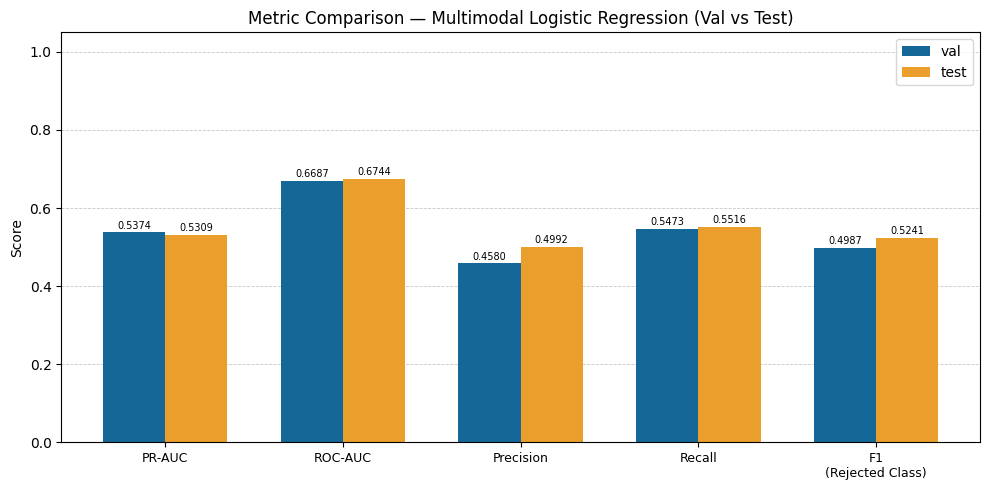

In [16]:
# Metric comparison bar chart (val vs test)
fig = plot_metric_bars(all_metrics, EVAL_DIR, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

### Validation Curves, Confusion Matrix, and Prediction Probabilities

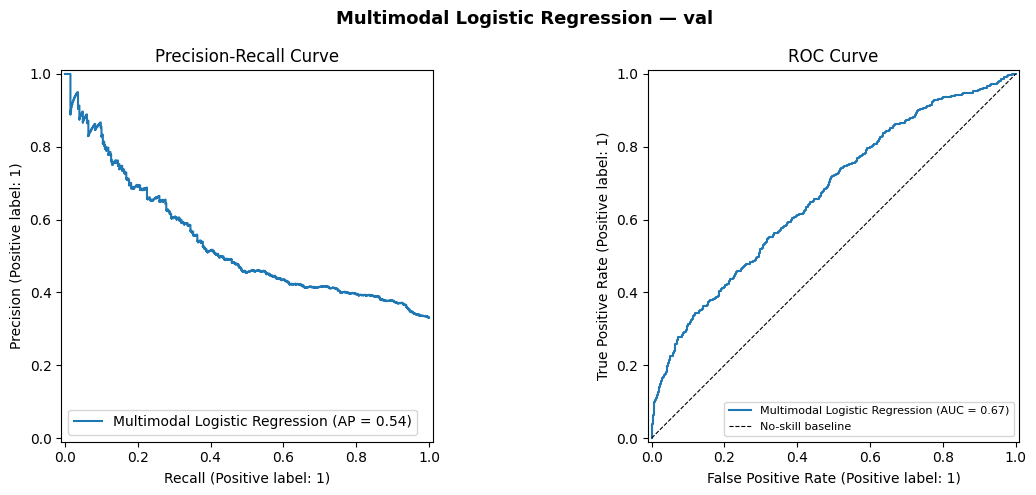

In [17]:
# Val PR-AUC and ROC-AUC curves
fig = plot_curves_summary(y_val, y_pred_val, y_prob_val, 'val', EVAL_DIR, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

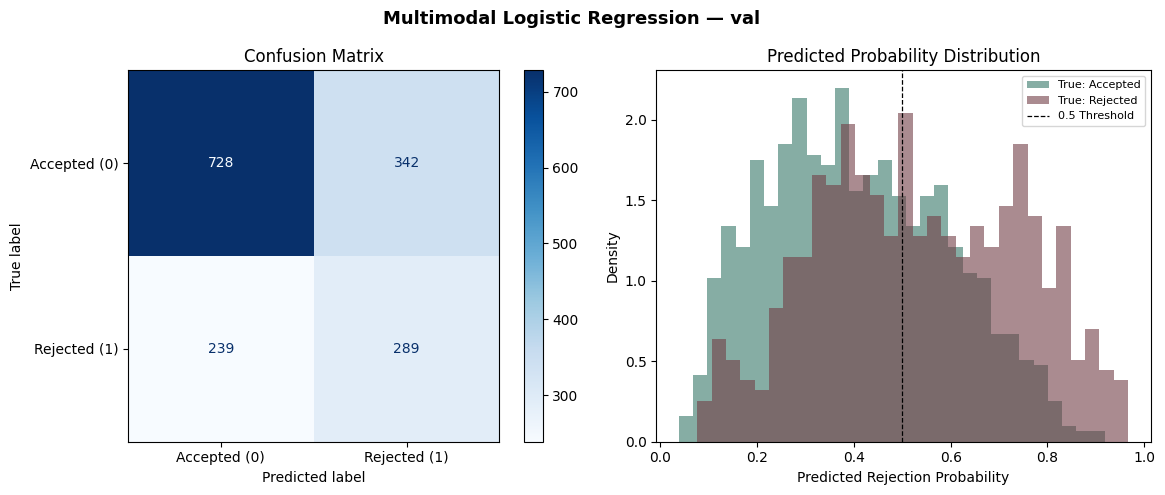

In [18]:
# Val confusion matrix and predicted probability distribution
fig = plot_diagnostics_summary(y_val, y_pred_val, y_prob_val, 'val', EVAL_DIR, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

### Test Curves, Confusion Matrix, and Prediction Probabilities

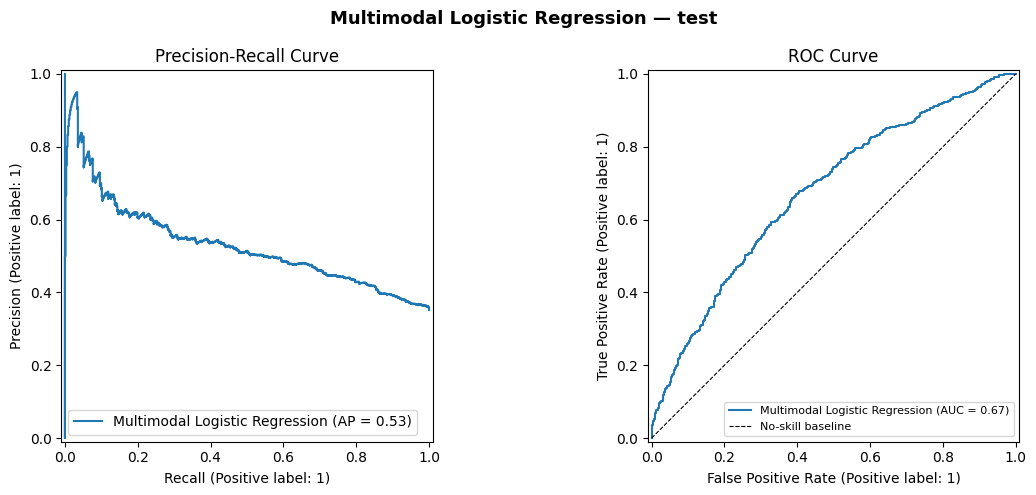

In [19]:
# Test PR-AUC and ROC-AUC curves
fig = plot_curves_summary(y_test, y_pred_test, y_prob_test, 'test', EVAL_DIR, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

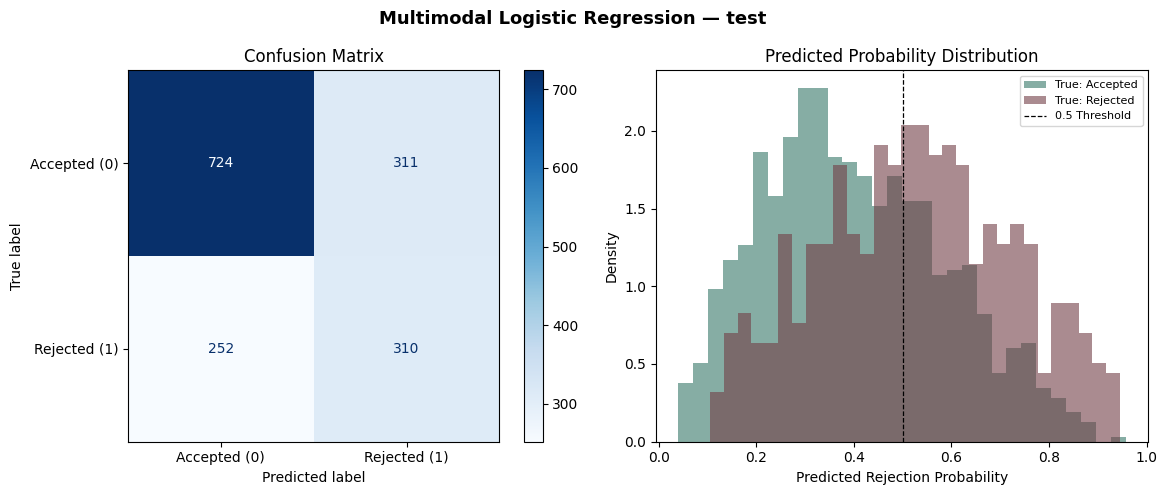

In [20]:
# Test confusion matrix and predicted probability distribution
fig = plot_diagnostics_summary(y_test, y_pred_test, y_prob_test, 'test', EVAL_DIR, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

### Group Ablation

Ablation C: 0.1  (reused from regularization tuning)
No-skill PR-AUC baseline: 0.3519


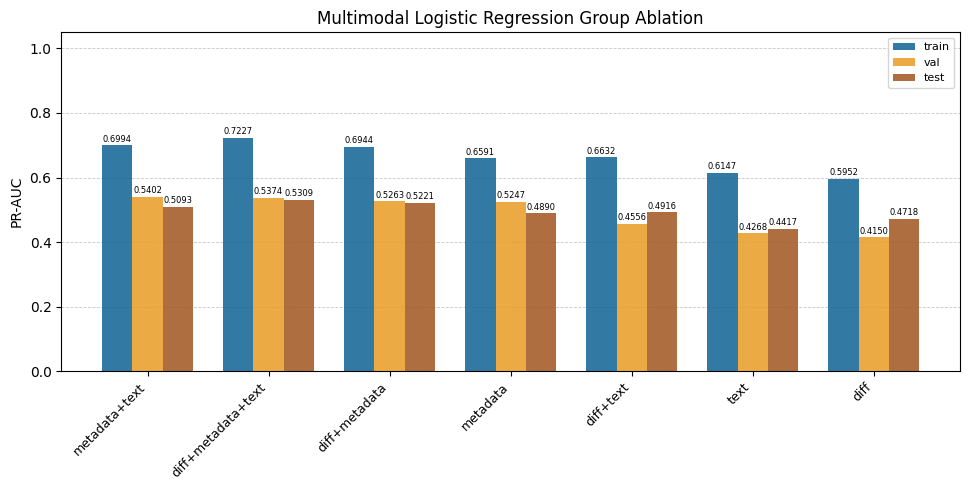

In [21]:
# Group ablation study
# Reuse best_C  same criterion (val PR-AUC), same feature matrix.
best_C_abl = best_C
print(f"Ablation C: {best_C_abl}  (reused from regularization tuning)")

# Run the full ablation with tuned C.
# Trains LR on every non-empty subset of feature groups.
# PR-AUC (primary) and ROC-AUC (secondary) recorded for train/val/test.

# Compute for no-skill baseline.
majority_class_proportion = float((y_test == 1).sum() / len(y_test))
print(f"No-skill PR-AUC baseline: {majority_class_proportion:.4f}")

ablation_df = run_group_ablation(
    group_slices=pipeline.group_slices_,
    X_train=X_full_train, y_train=y_train,
    X_val=X_full_val,     y_val=y_val,
    X_test=X_full_test,   y_test=y_test,
    eval_dir=EVAL_DIR,
    model_name="multimodal_lr",
    C=best_C_abl,
    random_state=42,
    display_fn=ipy_display,
)

In [22]:
# Ablation tabular summary (from already-computed ablation_df)
display_cols = [
    'combination', 'n_features',
    'train_pr_auc', 'val_pr_auc', 'test_pr_auc',
    'train_val_gap',
]
ipy_display(
    ablation_df[display_cols]
    .sort_values('test_pr_auc', ascending=False)
    .reset_index(drop=True)
    .round(4)
)

,combination,n_features,train_pr_auc,val_pr_auc,test_pr_auc,train_val_gap
0,diff+metadata+text,1221,0.7227,0.5374,0.5309,0.1853
1,diff+metadata,837,0.6944,0.5263,0.5221,0.1681
2,metadata+text,453,0.6994,0.5402,0.5093,0.1592
3,diff+text,1152,0.6632,0.4556,0.4916,0.2076
4,metadata,69,0.6591,0.5247,0.4890,0.1344
5,diff,768,0.5952,0.4150,0.4718,0.1802
6,text,384,0.6147,0.4268,0.4417,0.1879


### Subgroup performance analyses
Subgroup performance is only done for the primary model (with the default 0.5 threshold) because PR-AUC, the main metric used for this subgroup analyses, is unaffected by threshold optimization.

In [23]:
# Load task_type table and define subgroup helpers

_task_type_df = load_raw_tables(['pr_task_type'])['pr_task_type']
_task_type_map = (
    _task_type_df.drop_duplicates('id')
    .set_index('id')['type']
)

def _get_task_type(split_df):
    return split_df['id'].map(_task_type_map).fillna('unknown').values

_DIFF_BINS   = [0, 50, 100, 250, 500, 1000, float('inf')]
_DIFF_LABELS = ['<=50', '51-100', '101-250', '251-500', '501-1000', '>1000']

def _quarter_label(dt_series):
    dt = pd.to_datetime(dt_series)
    return (dt.dt.year.astype(str) + '-Q' + dt.dt.quarter.astype(str)).values

def _diff_size_bin(total_changes_series):
    return pd.cut(
        total_changes_series, bins=_DIFF_BINS, labels=_DIFF_LABELS, include_lowest=True,
    ).astype(str).values

print('Task type value counts:')
print(_task_type_map.value_counts())

Task type value counts:
type
feat        14450
fix          8106
docs         3887
test         2356
refactor     2288
chore         896
build         627
ci            411
perf          340
style         188
other          31
revert         16
Name: count, dtype: int64


#### Validation subgroups by agent, task type, programming language, and diff size bin

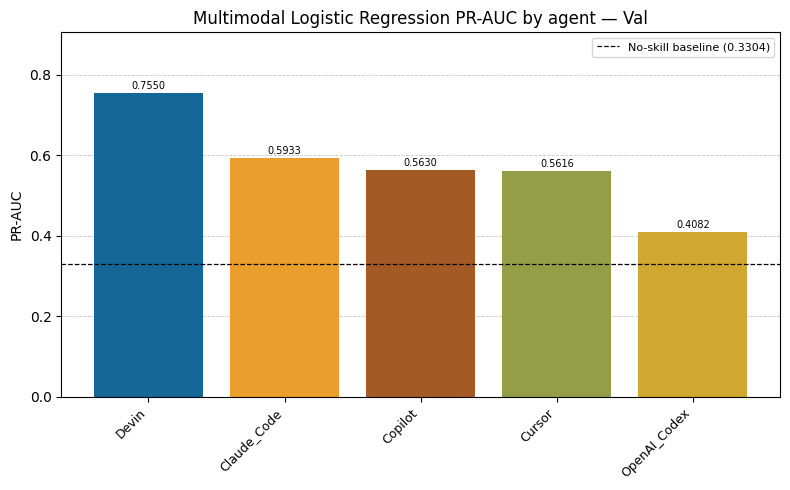

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Devin,179,0.296,0.7550,0.8559,0.4324,0.9057,0.5854,False
Claude_Code,42,0.381,0.5933,0.6803,0.4583,0.6875,0.5500,False
Copilot,536,0.386,0.5630,0.6587,0.4833,0.7005,0.5720,False
Cursor,312,0.260,0.5616,0.7131,0.5000,0.4444,0.4706,False
OpenAI_Codex,529,0.323,0.4082,0.5849,0.3952,0.2865,0.3322,False


In [24]:
# Val subgroup: agent
_ = run_subgroup_report(
    y_val, y_pred_val, y_prob_val,
    group_cols={'agent': val_df['agent'].values},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='val',
    filter_low_support_dims={'agent'},
    display_fn=ipy_display,
)

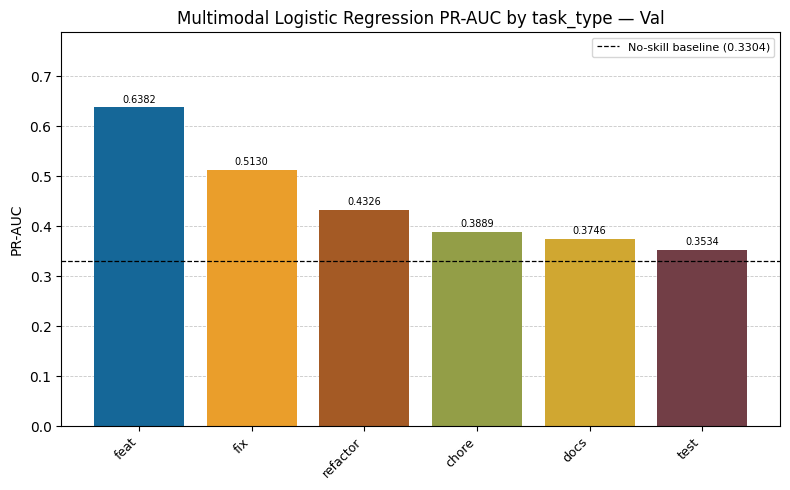

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
other,2,0.500,1.0000,1.0000,0.0000,0.0000,0.0000,True
perf,15,0.600,0.7002,0.6296,0.6364,0.7778,0.7000,True
build,29,0.345,0.6463,0.7579,0.7000,0.7000,0.7000,True
feat,605,0.392,0.6382,0.6746,0.5400,0.5696,0.5544,False
fix,483,0.317,0.5130,0.6632,0.4178,0.5817,0.4863,False
refactor,104,0.346,0.4326,0.6156,0.4250,0.4722,0.4474,False
ci,15,0.200,0.4250,0.7500,0.3333,0.3333,0.3333,True
chore,62,0.242,0.3889,0.5489,0.1500,0.2000,0.1714,False
docs,190,0.195,0.3746,0.6094,0.4000,0.3243,0.3582,False
test,84,0.321,0.3534,0.5374,0.3396,0.6667,0.4500,False


In [25]:
# Val subgroup: task type
_ = run_subgroup_report(
    y_val, y_pred_val, y_prob_val,
    group_cols={'task_type': _get_task_type(val_df)},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='val',
    filter_low_support_dims={'task_type'},
    display_fn=ipy_display,
)

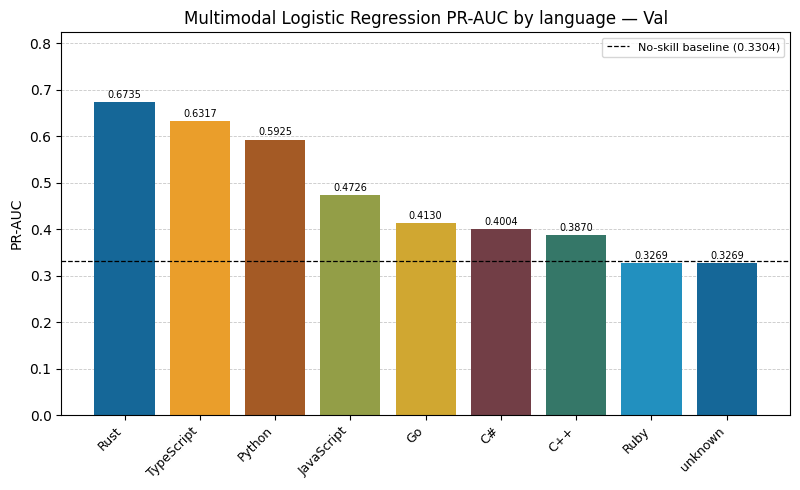

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Dart,2,0.500,1.0000,1.0000,1.0000,1.0000,1.0000,True
Zig,5,0.600,1.0000,1.0000,0.6000,1.0000,0.7500,True
PowerShell,4,0.750,1.0000,1.0000,1.0000,1.0000,1.0000,True
MoonBit,9,0.333,0.8667,0.8889,1.0000,0.3333,0.5000,True
Vue,12,0.333,0.8542,0.9062,1.0000,0.5000,0.6667,True
Java,29,0.379,0.8540,0.8232,0.6667,0.7273,0.6957,True
Swift,10,0.500,0.8393,0.7600,0.7500,0.6000,0.6667,True
Kotlin,9,0.778,0.8274,0.4286,0.6667,0.5714,0.6154,True
Rust,100,0.440,0.6735,0.7090,0.7037,0.4318,0.5352,False
TypeScript,479,0.347,0.6317,0.7301,0.5544,0.6446,0.5961,False


In [26]:
# Val subgroup: language
_ = run_subgroup_report(
    y_val, y_pred_val, y_prob_val,
    group_cols={'language': val_df['language'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='val',
    top_n_dims={'language': 10},
    filter_low_support_dims={'language'},
    display_fn=ipy_display,
)

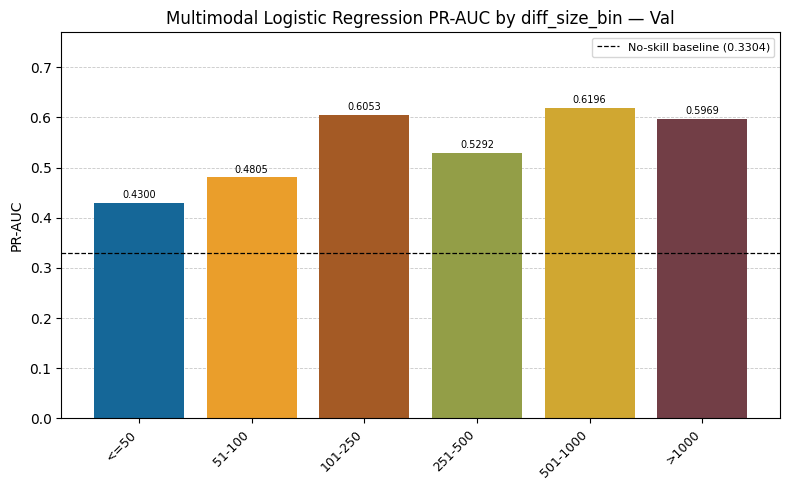

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
501-1000,129,0.349,0.6196,0.7241,0.4746,0.6222,0.5385,False
101-250,269,0.376,0.6053,0.6660,0.4715,0.5743,0.5179,False
>1000,319,0.360,0.5969,0.6527,0.4776,0.5565,0.5141,False
251-500,193,0.342,0.5292,0.6954,0.4636,0.7727,0.5795,False
51-100,180,0.361,0.4805,0.6389,0.4932,0.5538,0.5217,False
<=50,508,0.268,0.4300,0.6450,0.3939,0.3824,0.3881,False


In [27]:
# Val subgroup: diff size
_ = run_subgroup_report(
    y_val, y_pred_val, y_prob_val,
    group_cols={'diff_size_bin': _diff_size_bin(val_df['total_changes'])},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='val',
    category_orders={'diff_size_bin': _DIFF_LABELS},
    filter_low_support_dims={'diff_size_bin'},
    display_fn=ipy_display,
)

#### Test split subgroups by agent, task type, language and diff size bin

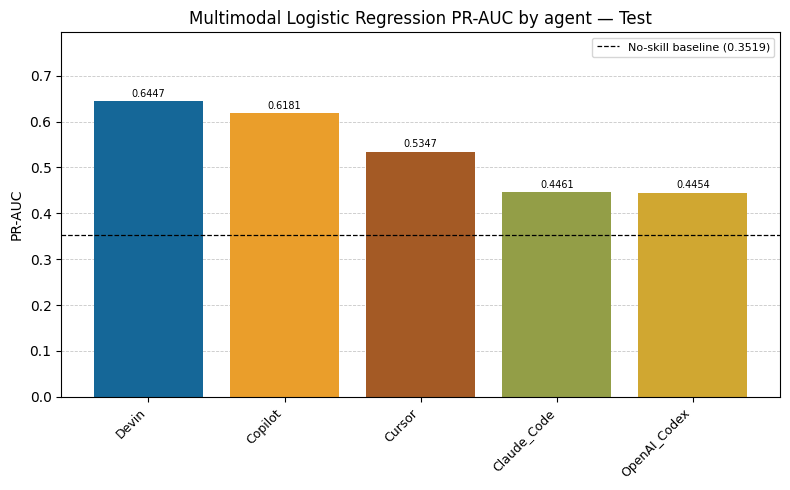

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Devin,227,0.308,0.6447,0.7805,0.4627,0.8857,0.6078,False
Copilot,480,0.419,0.6181,0.6971,0.5465,0.7313,0.6255,False
Cursor,256,0.289,0.5347,0.7144,0.4667,0.4730,0.4698,False
Claude_Code,62,0.419,0.4461,0.4861,0.4062,0.5000,0.4483,False
OpenAI_Codex,572,0.334,0.4454,0.6432,0.4775,0.2775,0.3510,False


In [28]:
# Test subgroup: agent
_ = run_subgroup_report(
    y_test, y_pred_test, y_prob_test,
    group_cols={'agent': test_df['agent'].values},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='test',
    filter_low_support_dims={'agent'},
    display_fn=ipy_display,
)

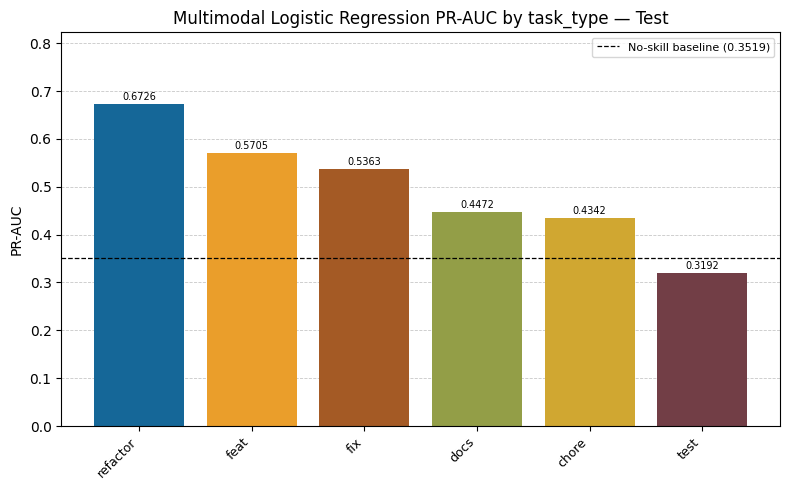

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
perf,12,0.333,0.7183,0.7188,0.4444,1.0000,0.6154,True
refactor,113,0.345,0.6726,0.7533,0.6216,0.5897,0.6053,False
style,16,0.188,0.6667,0.8718,0.3333,0.3333,0.3333,True
feat,609,0.429,0.5705,0.6374,0.5420,0.5441,0.5430,False
fix,501,0.351,0.5363,0.6702,0.4870,0.6364,0.5517,False
docs,215,0.214,0.4472,0.7040,0.4706,0.3478,0.4000,False
chore,36,0.361,0.4342,0.5987,0.3333,0.2308,0.2727,False
build,25,0.240,0.4103,0.5789,0.1667,0.1667,0.1667,True
test,43,0.233,0.3192,0.6000,0.2609,0.6000,0.3636,False
ci,21,0.048,0.0667,0.3000,0.0000,0.0000,0.0000,True


In [29]:
# Test subgroup: task type
_ = run_subgroup_report(
    y_test, y_pred_test, y_prob_test,
    group_cols={'task_type': _get_task_type(test_df)},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='test',
    filter_low_support_dims={'task_type'},
    display_fn=ipy_display,
)

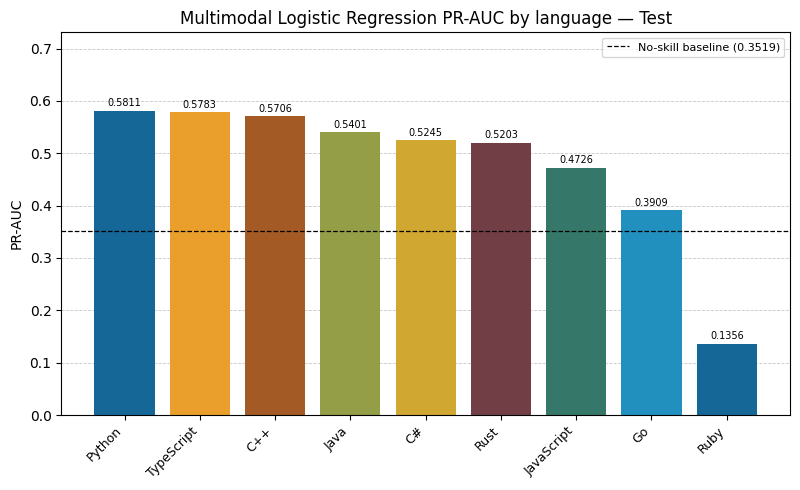

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
Vue,4,0.250,1.0000,1.0000,0.3333,1.0000,0.5000,True
Julia,3,0.667,1.0000,1.0000,0.6667,1.0000,0.8000,True
Bicep,7,0.571,0.9167,0.8333,1.0000,0.7500,0.8571,True
F#,7,0.571,0.9167,0.8333,0.5714,1.0000,0.7273,True
Swift,12,0.500,0.8168,0.7222,0.6667,0.6667,0.6667,True
Kotlin,11,0.727,0.8137,0.6250,0.7500,0.3750,0.5000,True
PHP,8,0.500,0.8042,0.8125,0.8000,1.0000,0.8889,True
Circom,15,0.533,0.7670,0.7321,1.0000,0.2500,0.4000,True
Jupyter Notebook,14,0.143,0.6429,0.7917,0.2500,1.0000,0.4000,True
C,24,0.333,0.5979,0.5859,1.0000,0.3750,0.5455,True


In [30]:
# Test subgroup: language
_ = run_subgroup_report(
    y_test, y_pred_test, y_prob_test,
    group_cols={'language': test_df['language'].fillna('unknown').values},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='test',
    top_n_dims={'language': 10},
    filter_low_support_dims={'language'},
    display_fn=ipy_display,
)

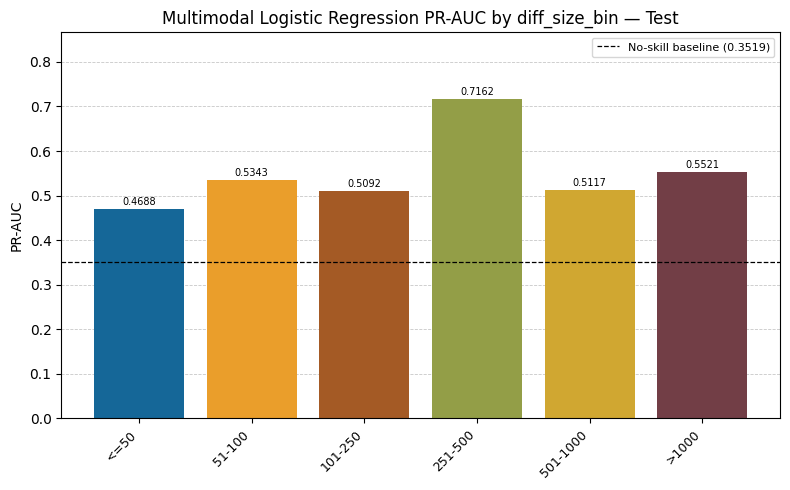

group_value,n_samples,rejection_rate,pr_auc,roc_auc,precision,recall,f1,low_support
251-500,175,0.463,0.7162,0.7445,0.6224,0.7531,0.6816,False
>1000,267,0.412,0.5521,0.5732,0.4519,0.5545,0.4980,False
51-100,221,0.330,0.5343,0.6666,0.4667,0.4795,0.4730,False
501-1000,137,0.365,0.5117,0.6839,0.5161,0.6400,0.5714,False
101-250,286,0.402,0.5092,0.6102,0.4878,0.5217,0.5042,False
<=50,511,0.260,0.4688,0.6846,0.4766,0.4586,0.4674,False


In [31]:
# Test subgroup: diff size
_ = run_subgroup_report(
    y_test, y_pred_test, y_prob_test,
    group_cols={'diff_size_bin': _diff_size_bin(test_df['total_changes'])},
    eval_dir=EVAL_DIR, model_name='multimodal_lr', split_name='test',
    category_orders={'diff_size_bin': _DIFF_LABELS},
    filter_low_support_dims={'diff_size_bin'},
    display_fn=ipy_display,
)

## Threshold optimization (supplementary)
This section sweeps decision thresholds from 0.10 to 0.90 to identify the
threshold that maximizes F1 on the validation set, applied to the test set
for reporting. This is a supplementary finding only; the primary reported
metrics throughout this thesis use the default threshold of 0.5 for
cross-model consistency. PR-AUC, the primary metric, is threshold-independent
and is unaffected by this analysis.

In [32]:
# Threshold optimization

# Extract probabilities
y_prob_val  = model.predict_proba(X_full_val)[:, 1]
y_prob_test = model.predict_proba(X_full_test)[:, 1]

thresholds = np.arange(0.10, 0.90, 0.01)
val_f1s = [
    f1_score(y_val, (y_prob_val >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresholds
]

best_t = thresholds[np.argmax(val_f1s)]
best_val_f1 = max(val_f1s)
default_val_f1 = f1_score(y_val, (y_prob_val >= 0.5).astype(int), pos_label=1, zero_division=0)

print(f"Default threshold (0.50) — Val F1: {default_val_f1:.4f}")
print(f"Optimal threshold ({best_t:.2f}) — Val F1: {best_val_f1:.4f}")
print(f"Delta: {best_val_f1 - default_val_f1:+.4f}\n")

# Apply optimized threshold to test set
y_pred_test_opt = (y_prob_test >= best_t).astype(int)

test_f1_opt   = f1_score(y_test, y_pred_test_opt, pos_label=1, zero_division=0)
test_prec_opt = precision_score(y_test, y_pred_test_opt, pos_label=1, zero_division=0)
test_rec_opt  = recall_score(y_test, y_pred_test_opt, pos_label=1, zero_division=0)
test_f1_def   = f1_score(y_test, (y_prob_test >= 0.5).astype(int), pos_label=1, zero_division=0)

print(f"Test results — rejected class:")
print(f"  Default (0.50) : F1={test_f1_def:.4f}")
print(f"  Optimised ({best_t:.2f}): F1={test_f1_opt:.4f}  Precision={test_prec_opt:.4f}  Recall={test_rec_opt:.4f}")
print(f"  Delta F1: {test_f1_opt - test_f1_def:+.4f}")
print(f"\nNote: PR-AUC (primary metric) is threshold-independent and unchanged.\n")

# Full metrics table: default threshold vs optimized threshold
opt_metrics = {}
for col_key, y_pred_col, y_prob_col, y_true_col in [
    ('val_def',  (y_prob_val  >= 0.5   ).astype(int), y_prob_val,  y_val),
    ('val_opt',  (y_prob_val  >= best_t).astype(int), y_prob_val,  y_val),
    ('test_def', (y_prob_test >= 0.5   ).astype(int), y_prob_test, y_test),
    ('test_opt', (y_prob_test >= best_t).astype(int), y_prob_test, y_test),
]:
    opt_metrics[col_key] = compute_metrics(y_true_col, y_pred_col, y_prob_col, col_key)

col_w = 18
col_labels = ['val (0.50)', f'val ({best_t:.2f})', 'test (0.50)', f'test ({best_t:.2f})']
col_keys   = ['val_def', 'val_opt', 'test_def', 'test_opt']
header = f"{'Metric':<28}" + "".join(f"{h:>{col_w}}" for h in col_labels)
print(header)
print('-' * (28 + col_w * len(col_labels)))
for key, label in METRIC_LABELS.items():
    row = f"{label:<28}"
    for ck in col_keys:
        row += f"{str(opt_metrics[ck].get(key, '')):>{col_w}}"
    print(row)

Default threshold (0.50) — Val F1: 0.4987
Optimal threshold (0.30) — Val F1: 0.5356
Delta: +0.0369

Test results — rejected class:
  Default (0.50) : F1=0.5241
  Optimised (0.30): F1=0.5559  Precision=0.4120  Recall=0.8541
  Delta F1: +0.0318

Note: PR-AUC (primary metric) is threshold-independent and unchanged.

Metric                              val (0.50)        val (0.30)       test (0.50)       test (0.30)
----------------------------------------------------------------------------------------------------
N samples                                 1598              1598              1597              1597
N positive (rejected)                      528               528               562               562
Accuracy                                0.6364            0.5063            0.6475            0.5197
Balanced Accuracy                       0.6139            0.5963            0.6256            0.5961
Precision (class 1)                      0.458            0.3886            0.4

### Evaluation (Threshold Optimization)

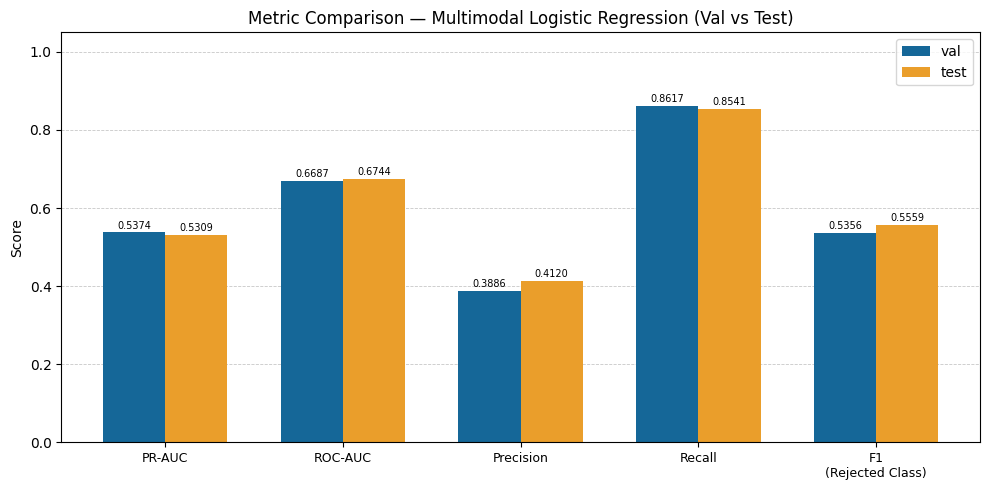

In [33]:
# Output directory setup
EVAL_DIR_OPT = EVAL_DIR

# Metric comparison bar chart — val vs test (optimised threshold)
_opt_comparison = {'val': opt_metrics['val_opt'], 'test': opt_metrics['test_opt']}
fig = plot_metric_bars(_opt_comparison, EVAL_DIR_OPT, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

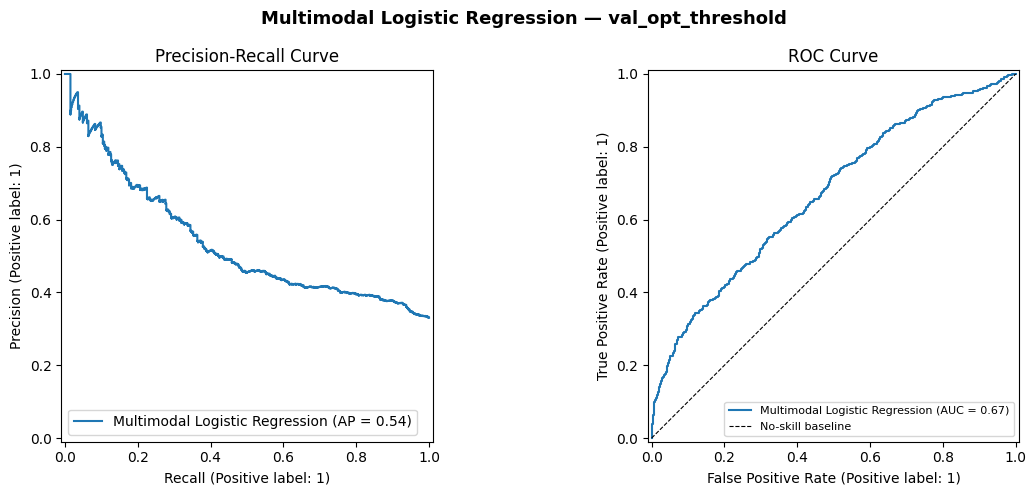

In [34]:
# Val PR-AUC and ROC-AUC curves (optimized threshold)
y_pred_val_opt = (y_prob_val >= best_t).astype(int)
fig = plot_curves_summary(y_val, y_pred_val_opt, y_prob_val, 'val_opt_threshold', EVAL_DIR_OPT, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

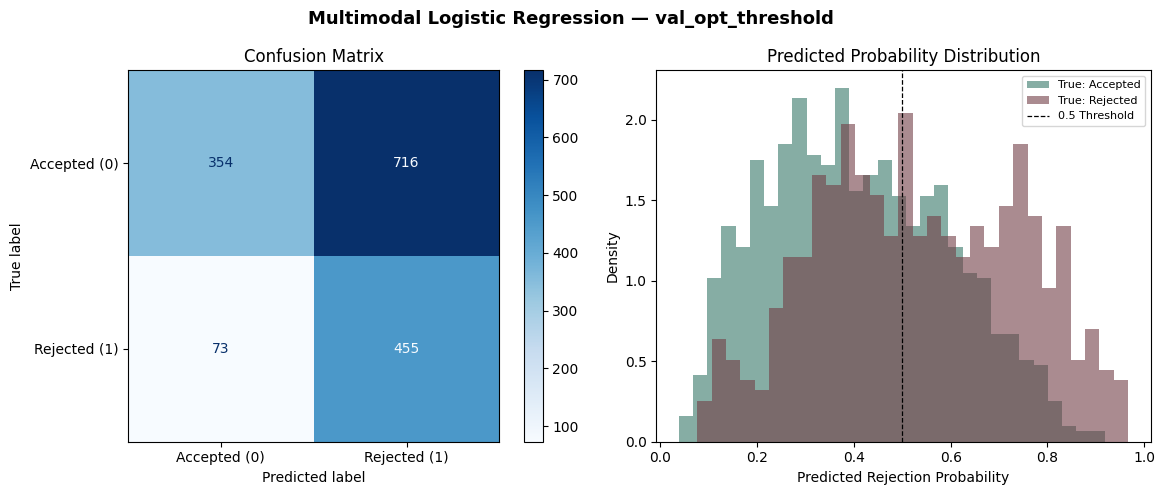

In [35]:
# Val confusion matrix and predicted probability distribution (optimized threshold)
fig = plot_diagnostics_summary(y_val, y_pred_val_opt, y_prob_val, 'val_opt_threshold', EVAL_DIR_OPT, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

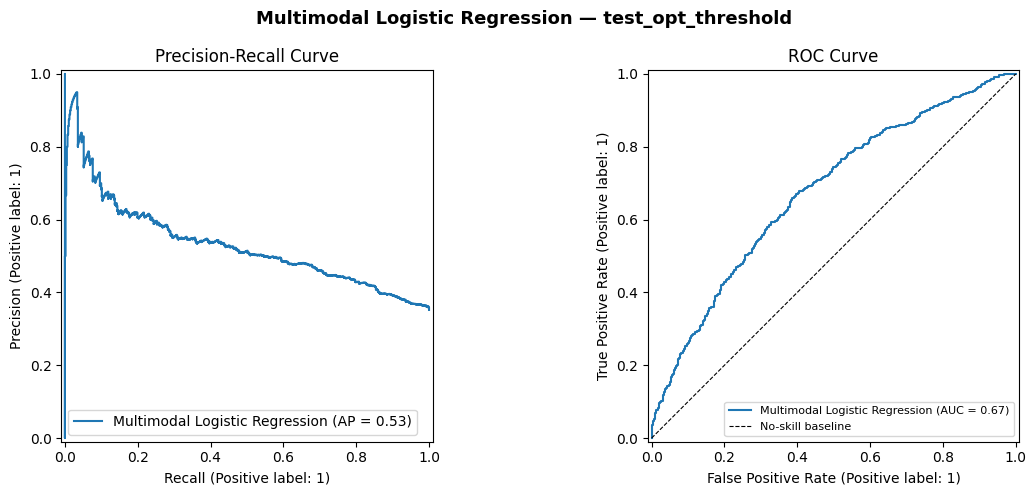

In [36]:
# Test PR-AUC and ROC-AUC curves (optimized threshold)
y_pred_test_opt = (y_prob_test >= best_t).astype(int)
fig = plot_curves_summary(y_test, y_pred_test_opt, y_prob_test, 'test_opt_threshold', EVAL_DIR_OPT, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

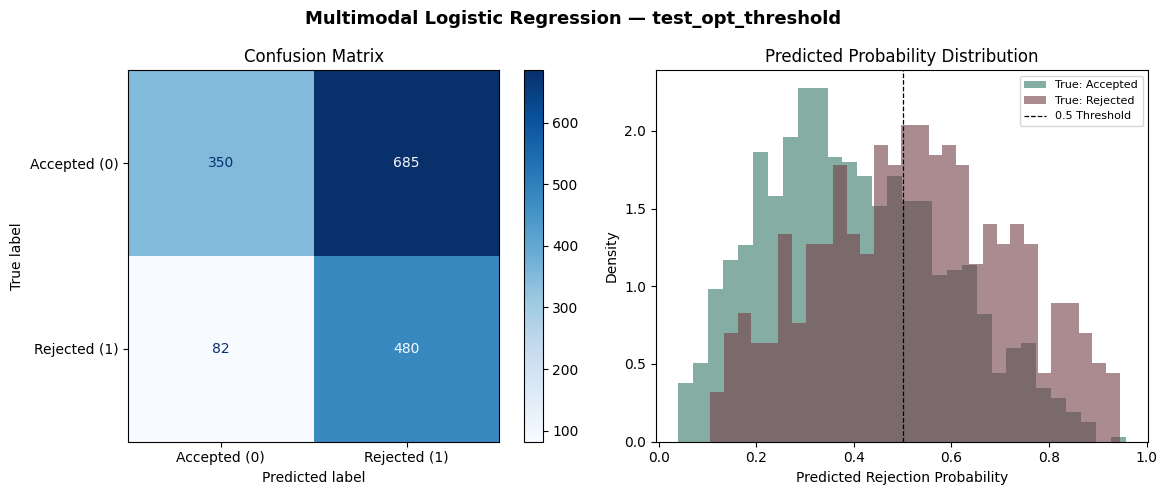

In [37]:
# Test confusion matrix and predicted probability distribution (optimized threshold)
fig = plot_diagnostics_summary(y_test, y_pred_test_opt, y_prob_test, 'test_opt_threshold', EVAL_DIR_OPT, model_name='multimodal_lr')
ipy_display(fig)
plt.close(fig)

In [38]:
# Prediction DataFrames — optimized threshold
def _build_predictions(df, y_pred, y_prob, split):
    out = df[['id', 'label']].rename(columns={'id': 'pr_id'}).copy().reset_index(drop=True)
    out['y_pred'] = y_pred
    out['rejection_probability'] = y_prob.round(4)
    out['correct'] = out['label'] == out['y_pred']
    out['split'] = split
    return out

results_val_opt  = _build_predictions(val_df,  y_pred_val_opt,  y_prob_val,  'val')
results_test_opt = _build_predictions(test_df, y_pred_test_opt, y_prob_test, 'test')

for name, df_res in [('val', results_val_opt), ('test', results_test_opt)]:
    out_path = MODELS_DIR / f'multimodal_lr_predictions_{name}_opt_threshold.csv'
    df_res.to_csv(out_path, index=False)
    print(f'{name}: {len(df_res)} PRs saved to {out_path}')


val: 1598 PRs saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/multimodal_lr_predictions_val_opt_threshold.csv
test: 1597 PRs saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/multimodal_lr_predictions_test_opt_threshold.csv


In [39]:
# Prediction DataFrames — default threshold (0.5)
results_val  = _build_predictions(val_df,  y_pred_val,  y_prob_val,  'val')
results_test = _build_predictions(test_df, y_pred_test, y_prob_test, 'test')

for name, df_res in [('val', results_val), ('test', results_test)]:
    out_path = MODELS_DIR / f'multimodal_lr_predictions_{name}.csv'
    df_res.to_csv(out_path, index=False)
    print(f'{name}: {len(df_res)} PRs saved to {out_path}')

val: 1598 PRs saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/multimodal_lr_predictions_val.csv
test: 1597 PRs saved to /content/drive/MyDrive/Thesis/AgenticPRRejection/results/final/multimodal_lr/multimodal_lr_predictions_test.csv
